In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
import matplotlib.pyplot as plt

In [5]:
X_train = np.load("X_train_multi.npy")  # Shape: (176485, 24, 1)
y_train = np.load("y_train_multi.npy")  # Shape: (176485, 4)
X_val   = np.load("X_val_multi.npy")    # Shape: (37594, 24, 1)
y_val   = np.load("y_val_multi.npy")    # Shape: (37594, 4)
X_test  = np.load("X_test_multi.npy")   # Shape: (37221, 24, 1)
y_test  = np.load("y_test_multi.npy")   # Shape: (37221, 4)

scaler = joblib.load("scaler_multi.pkl")  # Multi-patient scaler

In [6]:
print("MULTI-PATIENT DATASET SHAPES:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print(f"\nLookback: {X_train.shape[1]} timesteps, Horizon: {y_train.shape[1]} steps")

# ==================== 2. SHUFFLE TRAINING DATA ====================
print("\nShuffling training data...")
indices = np.random.permutation(len(X_train))
X_train = X_train[indices]
y_train = y_train[indices]

MULTI-PATIENT DATASET SHAPES:
X_train: (176485, 24, 1) y_train: (176485, 4)
X_val  : (37594, 24, 1) y_val  : (37594, 4)
X_test : (37221, 24, 1) y_test : (37221, 4)

Lookback: 24 timesteps, Horizon: 4 steps

Shuffling training data...


In [7]:
# Build GRU model
model = Sequential()

# GRU layer
model.add(GRU(units=96, input_shape=(X_train.shape[1], X_train.shape[2]),
              return_sequences=True,recurrent_dropout=0.1))

model.add(BatchNormalization())

model.add(GRU(units=64, return_sequences=False))
model.add(BatchNormalization())

model.add(Dropout(0.3))

# Additional dense layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(y_train.shape[1]))

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

print("\nGRU Model Summary:")
model.summary()


GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 96)         │        28,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,468 (244.02 KB)

 Trainable params: 62,148 (242.77 KB)

 Non-trainable params: 320 (1.25 KB)

In [8]:
# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)  # More patience
checkpoint = ModelCheckpoint("best_gru_model.h5", monitor="val_loss", save_best_only=True)

In [9]:
# Train model with different batch size)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=48,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
3676/3677 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0767 - mae: 0.1544

3677/3677 ━━━━━━━━━━━━━━━━━━━━ 210s 55ms/step - loss: 0.0767 - mae: 0.1544 - val_loss: 0.0039 - val_mae: 0.0428
Epoch 2/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0049 - mae: 0.0509

3677/3677 ━━━━━━━━━━━━━━━━━━━━ 202s 55ms/step - loss: 0.0049 - mae: 0.0509 - val_loss: 0.0035 - val_mae: 0.0424
Epoch 3/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 205s 56ms/step - loss: 0.0043 - mae: 0.0479 - val_loss: 0.0039 - val_mae: 0.0452
Epoch 4/100
3676/3677 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0041 - mae: 0.0464

3677/3677 ━━━━━━━━━━━━━━━━━━━━ 209s 57ms/step - loss: 0.0041 - mae: 0.0464 - val_loss: 0.0034 - val_mae: 0.0415
Epoch 5/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 261s 57ms/step - loss: 0.0039 - mae: 0.0454 - val_loss: 0.0037 - val_mae: 0.0393
Epoch 6/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 261s 56ms/step - loss: 0.0038 - mae: 0.0447 - val_loss: 0.0040 - val_mae: 0.0487
Epoch 7/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 207s 56ms/step - loss: 0.0037 - mae: 0.0441 - val_loss: 0.0034 - val_mae: 0.0428
Epoch 8/100
3676/3677 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0036 - mae: 0.0434

3677/3677 ━━━━━━━━━━━━━━━━━━━━ 206s 56ms/step - loss: 0.0036 - mae: 0.0434 - val_loss: 0.0030 - val_mae: 0.0367
Epoch 9/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 207s 56ms/step - loss: 0.0036 - mae: 0.0431 - val_loss: 0.0030 - val_mae: 0.0368
Epoch 10/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0035 - mae: 0.0427

3677/3677 ━━━━━━━━━━━━━━━━━━━━ 277s 61ms/step - loss: 0.0035 - mae: 0.0427 - val_loss: 0.0030 - val_mae: 0.0362
Epoch 11/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 207s 56ms/step - loss: 0.0035 - mae: 0.0425 - val_loss: 0.0033 - val_mae: 0.0400
Epoch 12/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 204s 55ms/step - loss: 0.0034 - mae: 0.0422 - val_loss: 0.0031 - val_mae: 0.0371
Epoch 13/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 210s 57ms/step - loss: 0.0034 - mae: 0.0420 - val_loss: 0.0031 - val_mae: 0.0388
Epoch 14/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 225s 61ms/step - loss: 0.0035 - mae: 0.0423 - val_loss: 0.0030 - val_mae: 0.0361
Epoch 15/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 208s 56ms/step - loss: 0.0034 - mae: 0.0419 - val_loss: 0.0030 - val_mae: 0.0376
Epoch 16/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 205s 56ms/step - loss: 0.0034 - mae: 0.0417 - val_loss: 0.0035 - val_mae: 0.0420
Epoch 17/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 205s 56ms/step - loss: 0.0034 - mae: 0.0418 - val_loss: 0.0030 - val_mae: 0.0376
Epoch 18/100


3677/3677 ━━━━━━━━━━━━━━━━━━━━ 205s 56ms/step - loss: 0.0034 - mae: 0.0414 - val_loss: 0.0029 - val_mae: 0.0366
Epoch 20/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 204s 56ms/step - loss: 0.0033 - mae: 0.0414 - val_loss: 0.0031 - val_mae: 0.0396
Epoch 21/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 214s 58ms/step - loss: 0.0033 - mae: 0.0414 - val_loss: 0.0030 - val_mae: 0.0379
Epoch 22/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 205s 56ms/step - loss: 0.0033 - mae: 0.0413 - val_loss: 0.0033 - val_mae: 0.0421
Epoch 23/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 208s 57ms/step - loss: 0.0033 - mae: 0.0413 - val_loss: 0.0033 - val_mae: 0.0399
Epoch 24/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 266s 58ms/step - loss: 0.0034 - mae: 0.0413 - val_loss: 0.0031 - val_mae: 0.0387
Epoch 25/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 213s 58ms/step - loss: 0.0033 - mae: 0.0411 - val_loss: 0.0031 - val_mae: 0.0375
Epoch 26/100
3677/3677 ━━━━━━━━━━━━━━━━━━━━ 212s 58ms/step - loss: 0.0033 - mae: 0.0409 - val_loss: 0.0030 - val_mae: 0.0370
Epoch 27/100


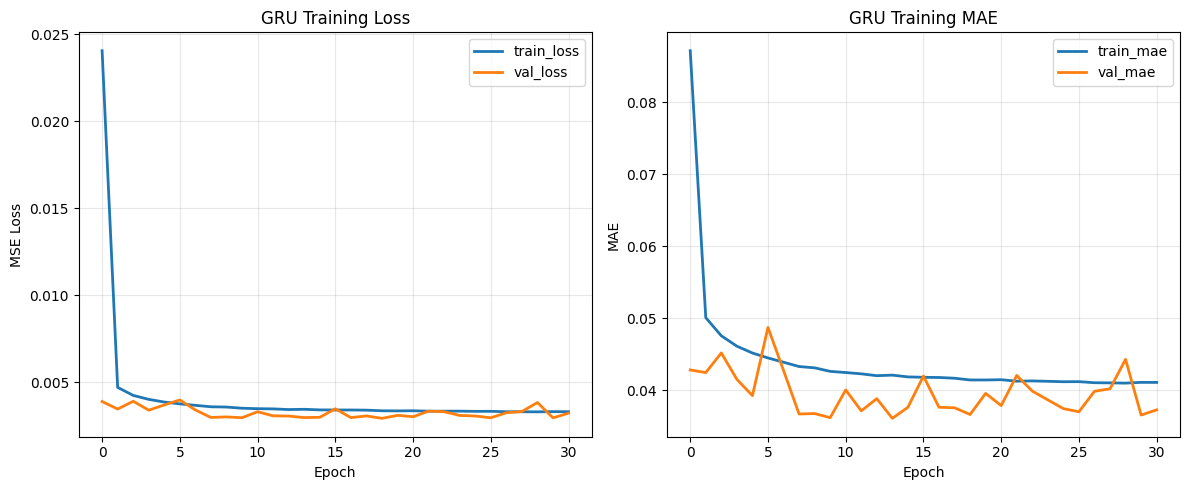

In [10]:
# Plot Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss", linewidth=2)
plt.plot(history.history["val_loss"], label="val_loss", linewidth=2)
plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train_mae", linewidth=2)
plt.plot(history.history["val_mae"], label="val_mae", linewidth=2)
plt.title("GRU Training MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Evaluate on Test Set
y_pred_scaled = model.predict(X_test)

# Inverse-transform function
def inverse_transform_sequence(y_scaled, scaler):
    y_scaled_flat = y_scaled.flatten().reshape(-1, 1)
    y_real = scaler.inverse_transform(y_scaled_flat)
    return y_real.reshape(y_scaled.shape)

y_pred = inverse_transform_sequence(y_pred_scaled, scaler)
y_real = inverse_transform_sequence(y_test, scaler)

1164/1164 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step


In [12]:
# Calculate metrics
n_steps = y_real.shape[1]

print("GRU MODEL RESULTS")

for step in range(n_steps):
    rmse_step = np.sqrt(np.mean((y_real[:, step] - y_pred[:, step])**2))
    mae_step  = np.mean(np.abs(y_real[:, step] - y_pred[:, step]))
    mape_step = np.mean(np.abs((y_real[:, step] - y_pred[:, step]) / y_real[:, step])) * 100
    accuracy_step = 100 - mape_step

    print(f"\nStep {step+1} ({15*step + 15} min ahead):")
    print(f"  RMSE : {rmse_step:.2f} mg/dL")
    print(f"  MAE  : {mae_step:.2f} mg/dL")
    print(f"  MAPE : {mape_step:.2f} %")
    print(f"  Accuracy: {accuracy_step:.2f} %")


GRU MODEL RESULTS

Step 1 (15 min ahead):
  RMSE : 11.43 mg/dL
  MAE  : 7.86 mg/dL
  MAPE : 5.38 %
  Accuracy: 94.62 %

Step 2 (30 min ahead):
  RMSE : 19.26 mg/dL
  MAE  : 13.57 mg/dL
  MAPE : 9.38 %
  Accuracy: 90.62 %

Step 3 (45 min ahead):
  RMSE : 27.40 mg/dL
  MAE  : 19.68 mg/dL
  MAPE : 13.92 %
  Accuracy: 86.08 %

Step 4 (60 min ahead):
  RMSE : 33.67 mg/dL
  MAE  : 24.53 mg/dL
  MAPE : 17.50 %
  Accuracy: 82.50 %


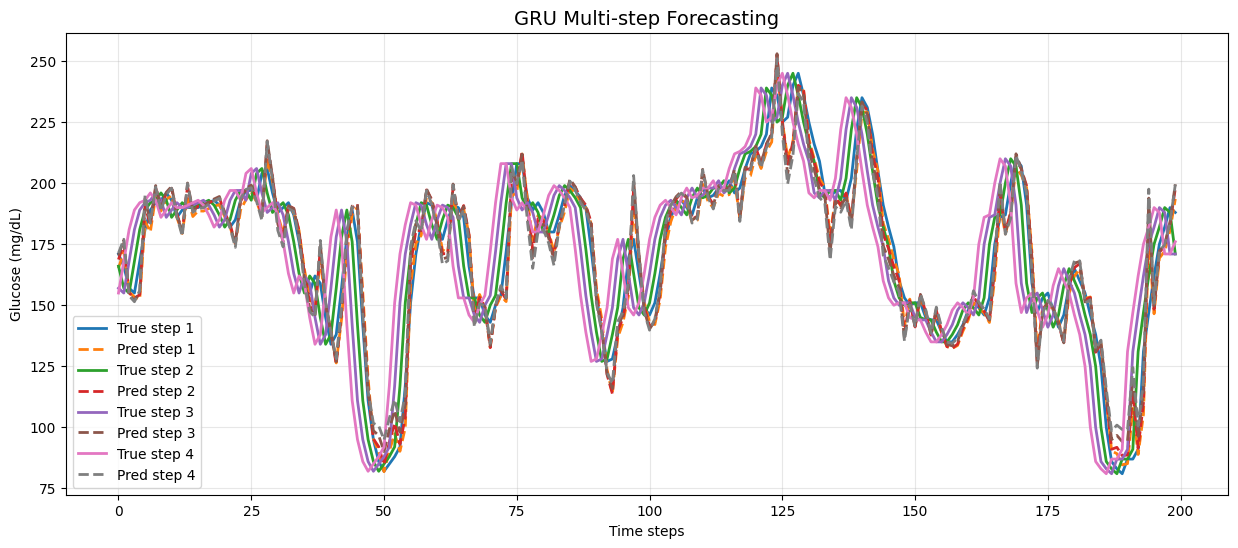

In [13]:
# Plot multi-step predictions
n_plot = 200
plt.figure(figsize=(15, 6))

for step in range(n_steps):
    plt.plot(y_real[:n_plot, step], label=f"True step {step+1}", linewidth=2)
    plt.plot(y_pred[:n_plot, step], linestyle="--", label=f"Pred step {step+1}", linewidth=2)

plt.title("GRU Multi-step Forecasting", fontsize=14)
plt.xlabel("Time steps")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# 15-min ahead analysis
y_real_15 = y_real[:, 0]
y_pred_15 = y_pred[:, 0]

rmse = np.sqrt(np.mean((y_real_15 - y_pred_15)**2))
mae = np.mean(np.abs(y_real_15 - y_pred_15))
mape = np.mean(np.abs((y_real_15 - y_pred_15) / y_real_15)) * 100
accuracy = 100 - mape

print("15-MINUTE AHEAD PREDICTION")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"MAPE: {mape:.2f} %")
print(f"Accuracy: {accuracy:.2f} %")

15-MINUTE AHEAD PREDICTION
RMSE: 11.43 mg/dL
MAE:  7.86 mg/dL
MAPE: 5.38 %
Accuracy: 94.62 %


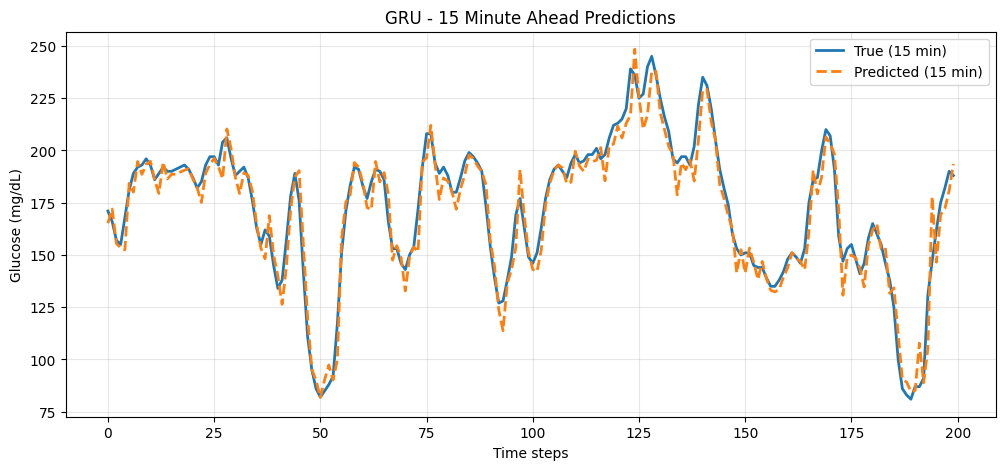

In [15]:
# Plot 15-min predictions
plt.figure(figsize=(12, 5))
plt.plot(y_real[:200, 0], label="True (15 min)", linewidth=2)
plt.plot(y_pred[:200, 0], linestyle="--", label="Predicted (15 min)", linewidth=2)
plt.title("GRU - 15 Minute Ahead Predictions")
plt.xlabel("Time steps")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()